# Проверка гипотезы в Python и составление аналитической записки

- Автор: Самонов Иван Андреевич
- Дата: 27.05.2026

## Цели и задачи проекта

**Цель проекта**: проверить гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы

**Задачи**: Провести статистический тест для проверки гипотезы.

## Описание данных

Данные из файла `yandex_knigi_data.csv`(SQL-запрос для формирования файла находится в `sql/Подготовка данных.sql`):


`city` - город пользователя<br>
`puid` - уникальный идентификатор пользователя<br>
`hours` - общее количество часов, которое пользователь проводит за чтением

## Содержимое проекта

1. Загрузка данных
2. Проверка на дубликаты в поле `puid`
3. Сравнение размеров групп, их статистики и распределение.
4. Проведение статистического теста
5. Аналитическая записка по результатам теста

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu 
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv('yandex_knigi_data.csv')

In [3]:
df_copy = df.copy()

In [4]:
display(df.head())
df.info()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [5]:
# Удаление столбца Unnamed: 0
df = df[['city', 'puid', 'hours']]

In [6]:
# Провекрка дубликатов в поле puid
dup_cnt = df['puid'].duplicated().sum()
print(f"Количество дубликатов в поле puid: {dup_cnt}")
print(f"Относительное выражение: {round((dup_cnt / df.shape[0])*100, 2)}%")

Количество дубликатов в поле puid: 244
Относительное выражение: 2.78%


In [7]:
# Удаление дубликатов
df = df[~df['puid'].duplicated()]

**Анализ выборок**

Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64

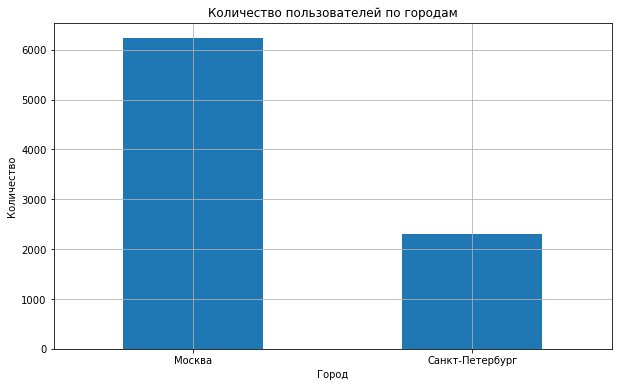

In [8]:
group_cnt = df['city'].value_counts()
group_cnt.plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0)
plt.title('Количество пользователей по городам')
plt.ylabel('Количество')
plt.xlabel('Город')
group_cnt

In [9]:
diff_ratio = abs(group_cnt.loc['Москва'] - group_cnt.loc['Санкт-Петербург']) / group_cnt.loc['Санкт-Петербург']
f"Разница между группами в {round(diff_ratio, 2)} раза"

'Разница между группами в 1.7 раза'

In [10]:
print("Среднее время, которое пользователи проводят за чтением по городам:")
df.groupby('city')['hours'].mean().reset_index()

Среднее время, которое пользователи проводят за чтением по городам:


,city,hours
0,Москва,10.881092
1,Санкт-Петербург,11.264433


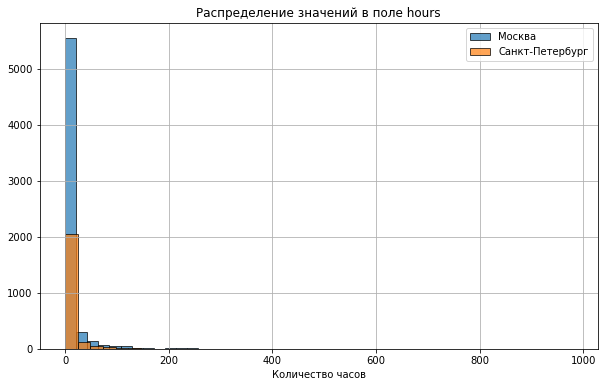

In [11]:
for column in ['Москва', 'Санкт-Петербург']:
    df[df['city'] == column]['hours'].plot(
        kind='hist',
        bins=40,
        figsize=(10, 6),
        edgecolor='Black',
        alpha=0.7,
        label=column)
plt.title('Распределение значений в поле hours')
plt.xlabel('Количество часов')
plt.ylabel('')
plt.legend()
plt.grid()

На графике видно, что в столбце есть выбросы. Их количество невелико, попробуем отобразить только значения ниже 99го процентиля.

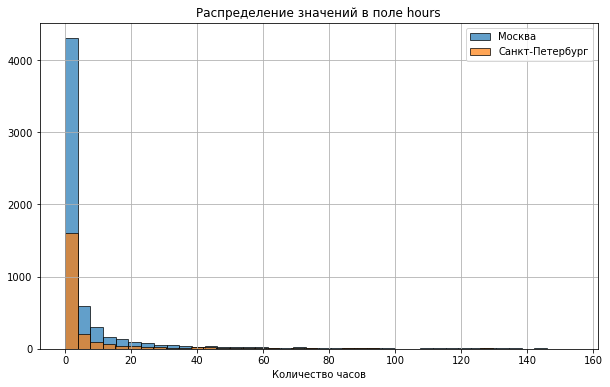

In [12]:
for column in ['Москва', 'Санкт-Петербург']:
    df[(df['city'] == column) & (df['hours'] <= df['hours'].quantile(0.99))]['hours'].plot(
        kind='hist',
        bins=40,
        figsize=(10, 6),
        edgecolor='Black',
        alpha=0.7,
        label=column)
plt.title('Распределение значений в поле hours')
plt.xlabel('Количество часов')
plt.ylabel('')
plt.legend()
plt.grid()

In [13]:
# Удалим выбросы выше 99го процентиля
df['hours'] = df[df['hours'] <= df['hours'].quantile(0.99)]['hours']

In [14]:
print(f"Строк отброшено: {df_copy.shape[0] - df.shape[0]}")
f"В процентах: {round(((df_copy.shape[0] - df.shape[0]) / df_copy.shape[0])*100, 2)}%"

Строк отброшено: 244


'В процентах: 2.78%'

## 2. Проверка гипотезы в Python

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [15]:
group_msk = df[df['city'] == 'Москва']['hours'].dropna()
group_SP = df[df['city'] == 'Санкт-Петербург']['hours'].dropna()

alpha = 0.05
mw_test = mannwhitneyu(
    group_msk,
    group_SP,
    alternative='less')
if mw_test.pvalue > alpha:
    print(f"p-value = {mw_test.pvalue}")
    print('Нулевая гипотеза находит подтверждение! Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается')
else:
    print(f"p-value = {mw_test.pvalue}")
    print('Нулевая гипотеза не находит подтверждение! Средняя активность пользователей в Санкт-Петербурге больше')

p-value = 0.6007990994240325
Нулевая гипотеза находит подтверждение! Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается


## 3. Аналитическая записка

В данных были обнаружены тяжелые хвосты, поэтому было принято решение использовать тесть Манна-Уитни, который решает эту проблему. Уровень статистической значимости выбран стандартный: 5%. В результате теста получили p-value = 0.6007990994240325, что значительно больше выбранного уровня статистической значимости. По итогам теста статистически не выявлены различия в средней активности пользователей из Москвы и Санкт-Петербурга. Скорее всего наблюдаемое различие среднего значения двух групп вызвано случайность.